![](https://www.dii.uchile.cl/wp-content/uploads/2021/06/Magi%CC%81ster-en-Ciencia-de-Datos.png)

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

### 👨‍🏫👩‍🏫 Cuerpo Docente:

- Profesor: Pablo Badilla, Diego Cortez
- Auxiliar: Melanie Peña Torres, Valentina Rojas Osorio
- Ayudante: Javiera Arévalo, Tamara Carrasco, Ignacio Reyes

### 👨‍💻👩‍💻 Estudiantes:
- Estudiante n°1: Javier Cruz Araneda
- Estudiante n°2: Enzo Toledo Venegas

_Por favor, lean detalladamente las instrucciones de la tarea antes de empezar a escribir._

---

## Reglas

El proyecto consta de 3 partes: **Informe de Análisis** (30%), **Construcción del Modelo** (40%) y **Despliegue del Modelo** (30%). Este notebook corresponde a la **Parte 2 - Construcción del Modelo**, y asume que ya completaste la **Parte 1 - Informe de Análisis**.

### **Requisitos del proyecto**
- **Grupos**: Formar equipos de **2 personas**.
- **Plazo de entrega**: Hasta el Viernes 10 de Julio
- **Consultas**: Cualquier duda fuera del horario de clases debe ser planteada en el foro correspondiente. Los mensajes enviados al equipo docente serán respondidos únicamente por este medio. Por favor, revisen las respuestas anteriores en el foro antes de realizar nuevas consultas.
- **Plagio**: La copia o reutilización no autorizada de trabajos de otros grupos está **estrictamente prohibida**. El incumplimiento de esta norma implicará la anulación inmediata del proyecto y una posible sanción académica.
- **Material permitido**: Pueden usar cualquier material del curso, ya sea notas, lecturas, códigos, o referencias proporcionadas por los docentes, que consideren útil para el desarrollo del proyecto.

---

## 📊 Distribución de Puntaje

La nota va de **1.0 a 7.0** (escala chilena): **1.0 de base + 6.0 puntos** repartidos como se muestra. Solo se evalúa **lo que implementas y respondes**; el **código y los recursos entregados no tienen puntaje**.

| Sección | Qué se evalúa | Puntaje |
|---|---|---:|
| **1 — Preparación** | 5 preguntas conceptuales (0.1 c/u) | 0.5 |
| **2 — Introducción a la Experimentación** | 3 preguntas (0.2 c/u) | 0.6 |
| **3 — Barrido de Combinaciones** | 10 experimentos (0.2 c/u) = 2.0 · preguntas LogReg 0.9 · Árbol/RF 0.2 · LightGBM 0.4 · MLP 0.4 | 3.9 |
| **4 — Selección del Mejor Modelo** | 5 preguntas (0.2 c/u) | 1.0 |
| | **Total puntos** | **6.0** |
| | **+ Base** | **1.0** |
| | **Nota máxima** | **7.0** |

> El puntaje de cada pregunta y experimento aparece **inline** como `(0.X pts)`.

Esta nota corresponde a la nota de la **Parte 2** que equivale a un **40%** de la nota del proyecto final. Para obtener la nota final, las notas individuales de cada parte se ponderan de la siguiente manera.

| Parte              | Ponderación |
|--------------------|------------:|
| 1 — Análisis       | 30%         |
| **2 — Modelo**     | **40%**     |
| 3 — Despliegue     | 30%         |


## 📖 Introducción

<p align="center">
    <img src="./chaucherapp.jpg" alt="Alt Text" width="700">
</p>

La app chilena **ChaucherApp** ha emergido recientemente como una de las nuevas apps *FinTech* que apuesta por dominar en un competitivo mercado. Esta app ofrece una billetera digital que permite hacer transferencias, tarjetas digitales que permiten comprar, y servicios financieros como préstamos, seguros e inversiones.

Sin duda es sorprendente que **ChaucherApp** sea uno de los líderes de la industria fintech, siendo una empresa tan joven. En las palabras del CEO de la empresa, el Sr. Querty _'El gran éxito de ChaucherApp se debe a que entendimos la importancia de escuchar y responder eficientemente al cliente'_. En efecto, **ChaucherApp** fue diseñada desde el comienzo con una robusta arquitectura digital relacionada al **Soporte al cliente**.

Durante años, **ChaucherApp** ha logrado dar respuesta satisfactoria a cientos de tickets de soporte al cliente al mes, lo que le ha permitido inspirar confianza y prestigio. Por supuesto, esto también ha generado una gran cantidad de datos que pueden ser útiles para las siguientes etapas de crecimiento de la empresa. Y es que, a medida que el mercado se hace más competitivo, se hace más necesario aumentar la eficiencia de los procesos de respuesta de tickets, por lo que el Sr. Querty ha optado por **automatizar el proceso** incorporando inteligencia artificial.

Luego de intensa planificación ejecutiva y jornadas de analítica, han decidido que el primer paso para automatizar será el de desarrollar un modelo de **priorización de tickets** de soporte al cliente utilizando **modelos de lenguaje** y **aprendizaje de máquinas**. De esta manera podrán optimizar recursos humanos mientras se desarrollan otras herramientas.

Para lograr esta tarea, te han encargado analizar datos históricos de tickets de soporte al cliente que ya han sido manualmente priorizados, presentes en el archivo `data/tickets.parquet`. En él, encontrarás tickets con el contenido del ticket, categoría, canal, fecha y priorización, que puede ser `Baja`, `Media`, `Alta` o `Crítica`. Tu objetivo es utilizar esa data y los medios, algoritmos y estrategias que estimes convenientes para construir un **modelo clasificador** que sea capaz de predecir esta categoría en base al texto y atributos del ticket.

Con esta información, tus tareas a realizar son primero **analizar y entender los datos**, luego **construir un modelo de inferencia**, y finalmente **implementar ese modelo** para que el equipo de ejecutivos de ChaucherApp pueda utilizarlo.

---

# Parte 2 - Construcción del Modelo

En la Parte 1 entendiste el problema y exploraste los datos. Recapitulemos lo que ya sabemos y que guiará todo este notebook:

- El problema es de **clasificación multiclase**: predecir `Nivel_Prioridad` ∈ {`Baja`, `Media`, `Alta`, `Critica`}.
- Las clases están **desbalanceadas** (Media ~39%, Baja ~36%, Alta ~17%, Critica ~7%).
- La variable `Tiempo_de_Resolución_Horas` es **data leakage** (no está disponible en inferencia), así que **no la usaremos**.
- Contamos con features de **texto** (`Asunto_Ticket`, `Contenido_Ticket`), **categóricas** (`Canal_Ticket`, `Categoría_Problema`), una **numérica** (`N_Caracteres_Ticket`) y los **embeddings** (`gemini-embedding-001`, 1024 dimensiones).
- Siguiendo la decisión de la Parte 1, la **métrica a optimizar será el _macro recall_** (promedio simple del recall por clase), para no descuidar a la clase `Critica`.

La idea de esta parte es experimentar con muchas combinaciones de **(features × modelo)**, optimizando los hiperparámetros con **Optuna** y registrando todo en **MLflow**, para finalmente elegir y exportar el mejor.

> **MLflow**: usaremos MLflow para *experiment tracking*. Como MLflow 3.x deprecó el backend de archivos, usaremos un backend de base de datos local (`sqlite:///mlflow.db`). Si no lo tienes instalado:
> ```bash
> uv pip install "mlflow>=3.14" ipywidgets optuna scikit-learn "pandas<3" optuna_integration lightgbm nltk
> ```
> Para abrir la interfaz gráfica y comparar tus runs:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```

In [5]:
!uv pip install "mlflow>=3.14" ipywidgets optuna scikit-learn "pandas<3" optuna_integration lightgbm nltk

Using Python 3.13.5 environment at: c:\Users\migue\Desktop\MDS7202\.venv
Checked 8 packages in 61ms


---

# Sección 1 - Preparación — (0.5 pts)

Antes de modelar, dejaremos listo el **protocolo experimental**: definir el split y la métrica y el ejecutor de experimentos antes de ejecutar cualquier experimento.

> Este código será dado, por ende, no tendrá puntaje.

Tareas de esta sección:

1. Importar librerías, configurar MLflow (tracking URI + experimento)., fijar semillas y definir las **constantes compartidas**.
2. Cargar `tickets.parquet` y `embeddings.parquet`. Descartar el *data leakage*, contruir una única columna de texto y armar un **único** dataframe `X_full` que contenga las features tabulares, el texto y las 1024 columnas de embedding.
3. Separar en **train / val / test (60/20/20) estratificado**.

In [ ]:
# ------------ 1. Importar librerías, fijar semillas y configurar constantes ------------

import re

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("sqlite:///mlflow.db")

try:
    mlflow.create_experiment("ProyectoMDS7202")

except:  # noqa: E722 (quitar ruff aqui porque sino no deja subirlo al repo)
    print("El experimento ya existe")
mlflow.set_experiment("ProyectoMDS7202")

# Definir constantes y fijar semillas
SEED = 42

np.random.seed(SEED)

ORDEN_CLASES = ["Baja", "Media", "Alta", "Critica"]
NUM_COLS = ["N_Caracteres_Ticket"]
CAT_COLS = ["Canal_Ticket", "Categoría_Problema"]
TEXT_COL = "Texto"

# ------------ 2. Cargar y preprocesar los datos ------------

# Cargar datos tabulares
df = pd.read_parquet("data/tickets.parquet")

# Descartamos la variable con data leakage detectada en la Parte 1
df = df.drop(columns=["Tiempo_de_Resolución_Horas"])

# Combinar campos de texto en una sola columna "Texto"
df["Texto"] = df["Asunto_Ticket"].fillna("") + " " + df["Contenido_Ticket"].fillna("")

# Cargar Embeddings (mismo orden de filas que df).
embeddings = pd.read_parquet("data/embeddings.parquet")
EMBEDDING_COLS = list(embeddings.columns)

# Generar único dataframe con todas las variables: tabular + texto + embeddings.
X_full = pd.merge(
    df.drop(columns=["Nivel_Prioridad", "Asunto_Ticket", "Contenido_Ticket"]),
    embeddings,
    on="Id_Ticket",
).drop(columns=["Id_Ticket"])
y = df["Nivel_Prioridad"]

print("---------- EDA Breve ----------\n")
print("X_full:", X_full.shape, "| columnas de embedding:", len(EMBEDDING_COLS))
print("Clases:", sorted(y.unique()))
display(X_full.head(10))
display(y.head(10))
display((y.value_counts() / len(y)).mul(100).round(2).rename("Distribución Labels (%)", inplace=True))

El experimento ya existe
---------- EDA Breve ----------

X_full: (2000, 1031) | columnas de embedding: 1024
Clases: ['Alta', 'Baja', 'Critica', 'Media']


,N_Caracteres_Ticket,Canal_Ticket,Categoría_Problema,Usuario-Tipo_de_Cuenta,Usuario-Antiguedad_Cuenta_Dias,Fecha_Envío,Texto,embedding_dim_1,embedding_dim_2,embedding_dim_3,...,embedding_dim_1015,embedding_dim_1016,embedding_dim_1017,embedding_dim_1018,embedding_dim_1019,embedding_dim_1020,embedding_dim_1021,embedding_dim_1022,embedding_dim_1023,embedding_dim_1024
0,531,Whatsapp,Cuenta,Premium,159,2024-01-02,Error al iniciar sesión en nuevo celular por d...,-0.011585,-0.008728,0.012878,...,-0.011539,-0.016249,0.004422,-0.022274,0.004511,0.001428,-0.007812,-0.020485,-0.001888,-0.000408
1,784,Whatsapp,Otro,Premium,192,2024-01-02,Error al actualizar correo electrónico: bloque...,0.014494,0.004070,0.011298,...,-0.019967,-0.008424,-0.002084,-0.002761,-0.004148,-0.007131,-0.012717,-0.019045,-0.015172,0.004308
2,600,Whatsapp,Fraude,Free,314,2024-01-02,Cobro desconocido en mi tarjeta digital Hola b...,-0.010936,0.020796,0.011680,...,-0.021763,-0.007094,-0.011453,-0.001084,-0.005820,-0.015085,0.003200,-0.019789,-0.018502,-0.001085
3,659,Whatsapp,Cuenta,Free,228,2024-01-02,"Cuenta bloqueada sin aviso, necesito ayuda urg...",0.003248,0.005420,0.003422,...,-0.019830,-0.007490,-0.013525,0.000086,-0.011983,0.007148,-0.002536,-0.016200,-0.003927,-0.004028
4,853,Whatsapp,Otro,Free,72,2024-01-03,Me descontaron plata del cajero y no salió el ...,-0.010437,0.013634,0.009859,...,-0.006401,-0.001971,0.002344,-0.010598,-0.011034,-0.012039,-0.000857,-0.009420,-0.006597,0.012463
5,672,Whatsapp,Otro,Free,71,2024-01-03,Problemas con retiro en cajero y saldo retenid...,-0.006699,0.015320,0.004916,...,-0.002004,-0.009383,0.002027,-0.004618,-0.005886,0.001436,-0.002760,-0.010959,-0.019190,0.013137
6,691,Correo,Cuenta,Free,27,2024-01-03,Problema con transferencia no recibida: dinero...,-0.001424,0.013316,-0.001574,...,-0.017849,0.000331,-0.004115,-0.007396,-0.016886,-0.004226,0.000309,-0.011096,-0.009890,0.001992
7,782,Whatsapp,Técnica,Free,193,2024-01-05,Error al acceder a la sección de inversiones (...,-0.001278,0.014927,0.002564,...,-0.021633,-0.006482,0.000185,-0.000037,-0.001324,-0.010792,0.003312,-0.020291,-0.002917,-0.004307
8,652,Página Web,Técnica,Free,283,2024-01-05,"Error en transferencia y saldo descontado, ayu...",0.003861,-0.008191,0.009408,...,-0.009119,-0.002006,0.003867,-0.010697,-0.020366,-0.003357,0.003855,-0.027547,-0.014218,0.010238
9,427,Whatsapp,Pregunta general,Free,72,2024-01-05,duda con inversiones y error en la app hola bu...,-0.010484,0.003417,0.022390,...,-0.016919,-0.004394,-0.004335,-0.009940,0.002788,-0.003919,0.001589,-0.023548,-0.008324,-0.010632


0     Baja
1    Media
2     Baja
3    Media
4    Media
5    Media
6    Media
7    Media
8    Media
9     Baja
Name: Nivel_Prioridad, dtype: object

Nivel_Prioridad
Media      39.45
Baja       36.15
Alta       17.50
Critica     6.90
Name: Distribución Labels (%), dtype: float64

In [7]:
# ------------ 3. Split train/val/test ------------

print("---------- Splits ----------\n")

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_full,
    y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=SEED,
)

print("Elementos por set | Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
d_y_train = (
    (y_train.value_counts() / len(y_train)).mul(100).round(2).rename("Distribución Labels Train (%)", inplace=True)
)
d_y_val = (y_val.value_counts() / len(y_val)).mul(100).round(2).rename("Distribución Labels Val (%)", inplace=True)
d_y_test = (y_test.value_counts() / len(y_test)).mul(100).round(2).rename("Distribución Labels Test (%)", inplace=True)
display(pd.concat([d_y_train, d_y_val, d_y_test], axis=1))

---------- Splits ----------

Elementos por set | Train: 1200 | Val: 400 | Test: 400


,Distribución Labels Train (%),Distribución Labels Val (%),Distribución Labels Test (%)
Nivel_Prioridad,,,
Media,39.42,39.5,39.50
Baja,36.17,36.0,36.25
Alta,17.50,17.5,17.50
Critica,6.92,7.0,6.75


Antes de modelar, responde:

1. ¿Por qué fijamos el split (train/val/test) **antes** de entrenar cualquier modelo? ¿Qué riesgo evitamos? **(0.1 pts)**
2. En general, siempre vamos a utilizar el enfoque de optimización de hiperparámetros. ¿Por qué utilizar train/val/test y no solo train/test es importante? ¿Qué otra técnica hay para evitar esto? **(0.1 pts)**
3. ¿Por qué usamos un split **estratificado**? ¿qué problema causaría un split aleatorio en val/test asumiendo que para esta cantidad de datos, la métricas pueden ser ruidosas? Apoya tu respuesta ejecutando el bloque `Split train/val/test` de la celda anterior comentando el parámetro `stratify` y justifica usando los resultados obtenidos. Luego, recuerda volver a agregar el parámetro, de lo contrario, tus resultados se podrían ver afectados. **(0.1 pts)**
4. ¿Por qué la métrica adecuada aquí es el **macro recall** y no, por ejemplo, el _accuracy_? Conéctalo con el desbalance y con lo que respondiste en la Parte 1. **(0.1 pts)**
5. ¿Qué es el **experiment tracking** y qué ganamos al registrar cada modelo en MLflow en lugar de solo imprimir métricas? Piensa en qué pasa si reinicias, por ejemplo, el notebook de Jupyter. **(0.1 pts)**

_Subtotal preguntas: 0.5 pts_

**Responde aquí**

> 1. Esto se hace para que el modelo únicamente se entrene con los datos de train sin nunca mirar val ni test. Esto ayuda a prevenir el **data leakage**, pues por ejemplo si tomaramos todos los datos y obtuvieramos una métrica como la mediana de alguna columna, al hacer el split después, el modelo ya sabría información que viene de val y test sí o sí lo que ya "contamina" las predicciones que vaya a realizar y lo hace menos confiable.

> 2. La razón es justamente la mencionada con la optimización de hiperparámetros. Primero, necesitamos train para entrenar un modelo, luego test para evaluar que su funcionamiento sea el correcto en datos nuevos, pero si realizamos optimización de parámetros solo en estos dos conjuntos estaríamos de una manera u otra ajustando el modelo para que funcione bien en test, por tanto realmente se sigue el siguiente esquema: `train` para entrenar el modelo inicial, `val` para optimizar hiperparámetros y finalmente `test` para evaluar el desempeño del modelo sobre datos nuevos que nunca se han visto antes (ni siquiera durante la optimización de hiperparámetros). Para evitar o complementar esto se suele usar **validación cruzada** de forma que en vez de tener un único conjunto de validación fijo, se va rotando y testeando en distintas particiones de train/test para evaluar el desempeño y finalmente se promedia el resultado, lo que permite generalizar igualmente un poco mejor el modelo.

> 3. El split estratificado ayuda a equilibrar el número de muestras para cada clase, de forma que en train, test y eval la proporción de cada una sea lo más similar posible. Podemos ver que para nuestra clase `Crítica` con split estratificado tenemos una diferencia entre el mayor y menor porcentaje de **0.25%**, sin embargo, si quitamos el stratify pasamos a una diferencia del **1.67%** que es casi 7 veces mayor, y un patrón similar existe para las otras clases. Es importante hacer el stratify sobre todo por las clases minoritarias como `Crítica` para **preservar la proporción de cada clase que hay en el dataset original**, de lo contrario, una clase podría verse sub o sobre representada afectando así todas las etapas del modelo. Con esto uno se asegura de tener algo más robusto y acorde a los datos originales.

> 4. En primer lugar, es fundamental usar **macro** pues le da el mismo peso a todas las clases, lo que evita que se prioricen las clases mayoritarias y en nuestro contexto eso es aún más importante, porque pese a que `Crítica` tiene bastantes menos casos que otras como `Media` o `Baja`, en la práctica se ponderan con la misma importancia para obtener la métrica que se esté evaluando. En segundo lugar, la métrica a tomar es el **recall** y no el accuracy, esto pues ambos priorizan cosas distintas. Nostros queremos un alto recall o alto accuracy, sin embargo, un alto recall viene dado conceptualmente por **evitar o minimizar los falsos negativos (FN)** mientras que accuracy busca evitar o minimizar el error sobre todas las clases a la vez, esto último puede ocultar lo bien que se comporte el modelo sobre nuestra clase `Crítica`, pues incluso si el modelo no fuera capaz de predecirla, esto quedaría oculto si el desempeño o detecciones de clases como `Media` o `Baja` fuera alto. Por esa razón, el **macro recall** es esencial. Evitar o minimizar los FN significa que no queremos clasificar mal una clase crítica y haberla hecho pasar por otra, lo que sería muy grave pues ese ticket se tomaría como menos prioritario pese a ser de urgencia (esto es muy similar al contexto médico donde por razones más o menos análogas el recall es esencial).

> 5. El **experiment tracking** es desarrollar un registro sistemático de cada ejecución y sus variantes que se hagan sobre modelos de machine learning. Es esencial para garantizar un fácil testeo de modelos con distintos hiperparámetros de forma ordenada y permitiendo **guardar resultados sin tener que recrearlos en cada nueva ejecución (reproducibilidad)** del modelo. Esto ayuda además a compartir los resultados con otras personas sin que deban perder tiempo en ejecutar todo desde cero, proporcionando un buen _checkpoint_ desde el cual partir o continuar con nuevos experimentos sobre el modelo que estemos creando. Finalmente, este mismo registro que permiten herramienta como **MLflow** permite **comparar fácil y rápidamente** combinaciones de hiperparámetros y modelos.

---

# Sección 2 - Introducción a la Experimentación — (0.6 pts)

La idea de la experimentación de este lab es que puedan probar muchas combinaciones de modelos y subconjuntos de features para resolver el problema.
Para no repetir el código de `Optuna` + `MLflow` una y otra vez, encapsularemos todo en **dos clases (ejecutor de experimentos y experimento abstracto) las cuales se te serán provistas**.

La idea de esta abstracción es finalmente que ustedes no definan el cómo ejecutan el experimento (código muy estándar), si no que simplemente definan la pipeline y el espacio de hiperparámetros a probar. 

- **`AbstractExperiment`**: define el *contrato* de un experimento. Cada experimento que ustedes hagan debe ser una **subclase** que implemente estos 4 métodos:
  - `model_name` (propiedad): Nombre del modelo a probar. Sirve para identificar el run.
  - `feature_set` (propiedad): Subconjunto de features a utilizar. Sirve para identificar el run.
  - `build_pipeline(hparams) -> Pipeline`: construye tu `ColumnTransformer` + modelo, parametrizado por `hparams`.
  - `generate_trial_hparams(trial) -> dict`: define el espacio de búsqueda de Optuna.
  
Mas adelante habrá un ejemplo de cómo implementar esto.

- **`ExperimentExecutor`**: recibe un experimento y se encarga del resto: corre **Optuna** (optimizando macro recall en **val**, cada *trial* como run anidado en MLflow), reentrena la mejor configuración con **train+val** y la evalúa en **test**, registrando todo en MLflow.

Esto nos garantiza que todos los modelos se comparen con el mismo protocolo.

In [8]:
import abc

import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
from optuna.integration.mlflow import MLflowCallback
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    recall_score,
)
from sklearn.pipeline import Pipeline


class AbstractExperiment(abc.ABC):
    """Experimento Abstracto.

    Permite que más adelante definan los experimentos a ejecutar.
    """

    @property
    @abc.abstractmethod
    def model_name(self) -> str:
        """Nombre del modelo, p.ej. 'Regresión_Logística', 'Arbol_de_Decision', 'LightGBM'..."""
        raise NotImplementedError()

    @property
    @abc.abstractmethod
    def feature_set(self) -> str:
        """Identificador del conjunto de features: 'Base', 'BoW', 'Embeddings', 'Todo', ..."""
        raise NotImplementedError()

    @property
    def study_name(self) -> str:
        """Identidad única de la combinación modelo × features. - Esta no debe ser redefinida"""
        return f"{self.model_name}__{self.feature_set}"

    @abc.abstractmethod
    def build_pipeline(self, hparams: dict) -> Pipeline:
        """Construye la pipeline a partir de los hiperparámetros entregados por Optuna.

        En este método deberán generar tanto el ColumnTransformer, como también el Pipeline,
        basándose en los parámetros entregados en hparams y dejando fijo el resto.
        Luego, deben retornar el Pipeline generado.
        """
        raise NotImplementedError()

    @abc.abstractmethod
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        """Genera los hiperparámetros a partir del trial de optuna que permitirán construir el pipeline.

        En este método deberán retornar un diccionario con los hiperparámetros generados por Optuna
        que luego, permitirán construir el Pipeline.

        Ejemplo:
        ```python
        return {"C": trial.suggest_float("C", 1e-3, 1e2, log=True)}
        ```
        """

        raise NotImplementedError()


class ExperimentExecutor:
    """Ejecutor de experimentos.

    Esta clase permite ejecutar un experimento de forma estandarizada y luego logear sus resultados a MLFlow.

    NO MODIFICAR.
    """

    def refit_and_eval_with_test(
        self,
        experiment: AbstractExperiment,
        best_params: dict,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        run_name: str,
        parent_run_id: str | None = None,
    ) -> float:
        """Reentrena con train+val la mejor config, evalúa en test (macro recall).

        Registra params/métricas/matriz de confusión/classification report en MLflow
        y devuelve el macro recall de test.
        """

        X_train_final = pd.concat([X_train, X_val], axis=0)
        y_train_final = pd.concat([y_train, y_val], axis=0)
        trained_pipeline = experiment.build_pipeline(best_params).fit(X_train_final, y_train_final)

        # evalúa sobre el conjunto con el que realmente se entrenó
        y_train_pred = trained_pipeline.predict(X_train_final)
        y_test_pred = trained_pipeline.predict(X_test)

        mr_final_train = float(recall_score(y_train_final, y_train_pred, average="macro"))
        mr_test = float(recall_score(y_test, y_test_pred, average="macro"))

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag("stage", "refit_final")
            mlflow.set_tag("study_name", experiment.study_name)
            # tags estructurados para agrupar/filtrar en la UI
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)
            if parent_run_id is not None:
                mlflow.set_tag("parent_run_id", parent_run_id)

            if best_params:
                mlflow.log_params(best_params)

            # tamaños de los splits para reproducibilidad
            mlflow.log_params(
                {
                    "n_train": len(X_train),
                    "n_val": len(X_val),
                    "n_train_final": len(X_train_final),
                    "n_test": len(X_test),
                }
            )

            mlflow.log_metric("macro_recall_final_train", mr_final_train)
            mlflow.log_metric("macro_recall_test", mr_test)

            # métricas por clase consultables desde el reporte como dict
            report_dict = classification_report(y_test, y_test_pred, output_dict=True)
            for label, metrics in report_dict.items():
                if isinstance(metrics, dict):
                    safe_label = str(label).replace(" ", "_")
                    mlflow.log_metric(f"recall_test_{safe_label}", metrics["recall"])
                    mlflow.log_metric(f"precision_test_{safe_label}", metrics["precision"])
                    mlflow.log_metric(f"f1_test_{safe_label}", metrics["f1-score"])

            fig, ax = plt.subplots(figsize=(4.5, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_test_pred,
                labels=ORDEN_CLASES,
                xticks_rotation=45,
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"{run_name} (test)")
            fig.tight_layout()
            mlflow.log_figure(fig, "matriz_confusion_test.png")
            plt.close(fig)

            # --- Permutation importance sobre el modelo refit (evaluada en test) ---
            # Permutamos cada columna de ENTRADA que el modelo realmente usa y medimos la caída
            # del macro recall. Con embeddings son cientos de columnas sin significado individual:
            # la idea es justamente evidenciar que no son interpretables una a una.
            ct_refit = trained_pipeline.steps[0][1]  # ColumnTransformer (1er paso del pipeline)
            used_cols = []
            for _, trans, cols in ct_refit.transformers_:
                if trans == "drop":
                    continue
                used_cols += [cols] if isinstance(cols, str) else list(cols)

            pi = permutation_importance(
                trained_pipeline,
                X_test[used_cols],
                y_test,
                scoring="recall_macro",
                n_repeats=5,
                random_state=SEED,
            )
            top = np.argsort(pi.importances_mean)[-20:]  # top-20 por importancia media
            fig_pi, ax_pi = plt.subplots(figsize=(6, max(3, 0.32 * len(top))))
            ax_pi.barh(
                [used_cols[i] for i in top],
                pi.importances_mean[top],
                xerr=pi.importances_std[top],
                color="#4C72B0",
            )
            ax_pi.set_xlabel("Caída de macro recall al permutar (importancia)")
            ax_pi.set_title(f"Permutation importance — {run_name} (top 20, test)")
            fig_pi.tight_layout()
            mlflow.log_figure(fig_pi, "permutation_importance_test.png")
            plt.close(fig_pi)

            clf_report = classification_report(y_test, y_test_pred, output_dict=False)
            mlflow.log_text(str(clf_report), "classification_report_test.txt")

            signature = mlflow.models.infer_signature(X_train_final, y_test_pred)
            # cloudpickle: el serializador estricto (skops) rechaza el tokenizador propio y joblib.Memory
            mlflow.sklearn.log_model(
                trained_pipeline,
                name="model",
                signature=signature,
                input_example=X_train_final.head(3),
                serialization_format="cloudpickle",
            )

        print(f"{run_name:32s} | Macro recall final_train={mr_final_train:.3f}  test={mr_test:.3f}")
        return mr_test

    def run_experiment(
        self,
        experiment: AbstractExperiment,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        timeout_seconds: int | None,
        n_trials: int | None,
    ):
        """Optimiza con Optuna (cada trial = run anidado en MLflow), reentrena la mejor
        configuración con train+val y la registra en un run de refit.

        NOTA: el experimento de MLflow se fija UNA vez fuera de este método
        (mlflow.set_experiment(...) en la Sección 0), de modo que todas las
        combinaciones modelo x features queden en el mismo experimento y comparables.
        """
        if not isinstance(experiment, AbstractExperiment):
            raise ValueError(
                f"El parámetro experiment debe implementar AbstractExperiment, se entregó: {type(experiment)}"
            )
        if timeout_seconds is not None and not isinstance(timeout_seconds, int):
            raise ValueError(f"timeout_seconds debe ser entero. Entregado: {type(timeout_seconds)}")
        if n_trials is not None and not isinstance(n_trials, int):
            raise ValueError(f"n_trials debe ser entero. Entregado: {type(n_trials)}")
        if (not timeout_seconds) and (not n_trials):
            raise ValueError("Al menos uno de timeout_seconds o n_trials debe ser distinto de nulo.")

        # callback nativo de Optuna: registra cada trial como run anidado
        mlflow_callback = MLflowCallback(
            metric_name="macro_recall_val",
            create_experiment=False,
            mlflow_kwargs={"nested": True},
        )

        with mlflow.start_run(run_name=f"{experiment.study_name}_search") as parent_run:
            parent_run_id = parent_run.info.run_id
            mlflow.set_tag("stage", "optuna_search")
            mlflow.set_tag("study_name", experiment.study_name)
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)

            @mlflow_callback.track_in_mlflow()
            def objective(trial):
                params = experiment.generate_trial_hparams(trial)
                pipe = experiment.build_pipeline(params).fit(X_train, y_train)
                mr_val = float(recall_score(y_val, pipe.predict(X_val), average="macro"))
                mlflow.log_params(params)
                mlflow.set_tag("trial_number", trial.number)
                return mr_val

            study = optuna.create_study(
                direction="maximize",
                study_name=experiment.study_name,
                sampler=optuna.samplers.TPESampler(seed=SEED),
            )
            study.optimize(
                objective,
                timeout=timeout_seconds,
                n_trials=n_trials,
                show_progress_bar=True,
                callbacks=[mlflow_callback],
            )

            # resumen de la búsqueda en el run padre
            mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
            mlflow.log_metric("best_macro_recall_val", float(study.best_value))
            mlflow.log_metric("n_trials_completed", len(study.trials))

            # visualizaciones de Optuna como artefactos del run padre
            try:
                history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
                mlflow.log_figure(history_fig.figure, "optuna_optimization_history.png")
                plt.close(history_fig.figure)

                importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
                mlflow.log_figure(importance_fig.figure, "optuna_param_importances.png")
                plt.close(importance_fig.figure)

                parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
                mlflow.log_figure(parallel_fig.figure, "optuna_parallel_coordinate.png")
                plt.close(parallel_fig.figure)
            except Exception as exc:  # la importancia falla con <2 trials o sin hiperparámetros
                print(f"No se pudieron generar visualizaciones de Optuna: {exc}")

        # refit fuera del run padre, enlazado por tag
        self.refit_and_eval_with_test(
            run_name=experiment.study_name,
            experiment=experiment,
            best_params=study.best_params,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            parent_run_id=parent_run_id,
        )
        return study


# Instanciamos el ejecutor de experimentos.
# Notar que es agnostico al experimento, así que no es necesario instanciarlo nuevamente.
exp_executor = ExperimentExecutor()

### Ejemplo trabajado: Baseline

A continuación entregamos un experimento **completo y comentado** que cumple dos roles: 

1. Ser el **template** que debes adaptar para tus propios experimentos 
2. Ser el **baseline** (una Regresión Logística usando solo las features tabulares). Fíjate en las cuatro piezas que todo experimento debe definir: 
    - `model_name`
    - `feature_set`
    - `build_pipeline`
    - `generate_trial_hparams`.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cache de pipelines: Cachea (guarda) y carga etapas de preprocesamiento para
# no recalcular etapas identicas entre distintas runs
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogisticRegressionWithBaseExperiment(AbstractExperiment):
    """Baseline: Regresión Logística sobre el feature-set base.

    Úsalo como molde para tus propios experimentos.
    """

    # 1. Definir nombre del modelo.
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    # 2. Definir la feature ser que se utilizará (Base, BoW, Embeddings, Full, Base+BoW, etc.)
    @property
    def feature_set(self) -> str:
        return "Base"

    # 3. Definir el ColumnTransformer + Pipeline
    def build_pipeline(self, hparams: dict) -> Pipeline:
        # 3.1. Preprocesamiento: escala las numéricas y codifica las categóricas.
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
            ]
        )
        # 3.2. Modelo: class_weight="balanced" para no ignorar a las clases minoritarias.
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        # 3.3. Pipeline
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,  # Importante: Debe ir siempre!
        )

    # 4. Generar el espacio de búsqueda de hiperparámetros de la pipeline para optuna.
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }

In [10]:
# Notar que tenemos los parámetros timeout_seconds y n_trials.
# Optuna se detendrá cuando ocurra el primero de estos.

exp_executor.run_experiment(
    experiment=LogisticRegressionWithBaseExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=50,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
c:\Users\mig

2026/07/08 19:33:14 INFO mlflow.models.model: Found the following environment variables used during model inference: [GOOGLE_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


Regresión_Logística__Base        | Macro recall final_train=0.543  test=0.495


### Leer y comparar tus experimentos en MLflow

Para abrir la interfaz y comparar tus runs:

> **Importante - El terminal debe estar en la misma carpeta que MLflow**. De lo contrario, no encontrarás ningún resultado.

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Abre el experimento **`ProyectoMDS7202`**. Para comparar las combinaciones (features × modelo):

- En la vista **Table**, agrega como columnas las métricas:
  - `macro_recall_val`: la que optimiza Optuna; vive en los runs `*_search`
  - `macro_recall_test`: la real; vive en los runs de **refit**, `stage=refit_final`.
- Agrupa o filtra por los **tags** `model_name` y `feature_set` para ver una fila por combinación. Filtra por `tags.stage = "refit_final"` para quedarte con los resultados finales.
- **Ordena por `macro_recall_val`** para rankear; y mira también `recall_test_Critica`: de nada sirve un macro alto si la clase crítica queda mal.
- En la vista **Chart** (o *parallel coordinates*) explora cómo cada hiperparámetro afecta el macro recall.
- En cada run de refit, pestaña **Artifacts**, encontrarás `matriz_confusion_test.png` y `classification_report_test.txt`; en el run `*_search`, el historial y la importancia de hiperparámetros de Optuna.

---

**Preguntas**:

1. ¿Qué ventajas tiene encapsular el flujo en `ExperimentExecutor` + `AbstractExperiment` en lugar de copiar/pegar el código de Optuna para cada modelo? (piensa en comparación justa, reproducibilidad y errores). **(0.2 pts)**
2. **Sobre el refit.** El ejecutor, tras la búsqueda, reentrena la mejor configuración con **train+val** y la evalúa en **test**. **(0.2 pts)**
   - (a) ¿Por qué reentrenar con `train+val` en vez de quedarnos con el modelo que ya se entrenó solo con `train` durante la búsqueda?
   - (b) Si el ejecutor calculara el `macro_recall_test` de cada experimento y nos quedáramos con este. ¿Sería correcto conceptualmente? ¿Qué riesgo nos implicaría "espiar" los resultados del test de todos los candidatos, y por qué seleccionar solo por val mantiene el problema acotado?
3. Es posible que los resultados de las métricas de test sean menor que las de validación (test < val), incluso, aunque el refit use más datos (train+val). ¿Por qué ocurre esto? (pista: ¿sobre que conjunto optimizamos durante la búsqueda?) **(0.2 pts)**

_Subtotal preguntas: 0.6 pts_

**Responde aquí**

> 1. Encapsular el flujo de esta forma permite realizar una **comparación justa** de las distintas combinaciones de features (hiperparámetros) con modelos, pues estos se realizan bajo una misma seed, mismo cálculo de métricas de evaluación, mismo número de trials a realizar, etc. Por otro lado, al establecer una seed fija y usar el enfoque de **experiment tracking** se garantiza la **reproducibilidad** de los datos, por tanto, además de la gran ventaja que es tener todos los experimentos realizados de forma sistemática para no tener que ejecutarlos nuevamente (fácilmente **compartibles a más personas**), en caso de ser necesaria una reejecución se obtendrían los mismos resultados lo que lo hace una forma robusta de probar modelos e hiperparámetros. Finalmente, esto ayuda a **reducir errores** o ser almenos consistente entre todos los modelos, pues se diseña una arquitectura general para ejecutar todo, por tanto, se garantiza que los errores humanos al copiar y pegar código se eviten.

> 2. **a)** Esto se realiza para poder tener más datos con los que entrenar el modelo. El único rol inicial del conjunto de validación `val` es la optimización de hiperparámetros, por tanto, una vez que se hizo esto y considerando que el modelo ya "vio" estos datos, es posible incorporarlos al conjunto de entrenamiento (ahora `train+val`) para tener así más datos con los que potencialmente el modelo pueda generalizar mejor al reentrenarlo. Esto es especialmente importante de realizar si se disponen de pocos datos. Además, esto no afecta en nada la evaluación del modelo con el conjunto de `test` pues el modelo no tiene acceso a este. **b)** **No sería correcto realizaro esto**, pues al mirar el `macro_recall_test` y usarlo para decidir estamos "mirando" el conjunto de `test` que debiera ser invisible para el modelo, por tanto tomar una decisión con esta métrica va a sesgar la elección de hiperparámetros o las decisiones que tomemos sobre como usar e interpretar el modelo, lo que potencialmente lleva a una mala generalización si este es llevado a producción. Esto no ocurre si usamos `val` puesto que este es usado solamente para la optimización de hiperparámetros y finalmente igual evaluamos el modelo en **datos nunca vistos por el** con el conjunto de `test`, por lo que esto sí garantiza que los resultados y métricas sean más generales al ser sobre datos nunca vistos antes.

> 3. Sí es posible que los resultados de **test < val** y de hecho sería lo esperable de cierta forma, esto pues el `val` es usado para buscar los mejores hiperparámetros para adaptar el modelo a este conjunto, por tanto, se suele optimizar para adaptarse mejor a este conjunto lo que aplica un sesgo al modelo, sin embargo, es por eso mismo que la evaluación real es sobre `test` que es inivisible para el mismo. Ahora bien, es cierto que al reentrenar con `train+val` debería mejorar la capacidad de generalización del modelo, pero normalmente no es suficiente para compensar el sesgo que se introdujo en la optimización de hiperparámetros lo que explica que igualmente **test < val** (aunque en un buen modelo tampoco deberían ser tan drásticos los cambios entre los resultados de uno y el otro).


---

# Sección 3 - Barrido de Combinaciones (features × modelo) — (3.9 pts)

Ahora que ya entendiste y experimentaste sobre el template, vamos a comenzar el proceso de experimentación.

Implementa una **subclase de `AbstractExperiment` por cada combinación (features × modelo)** y córrela con `exp_executor.run_experiment(...)`. **Cada combinación va en su propia subsección** (`3.1`, `3.2`, …) con su clase y su ejecución.

Iremos recorriendo distintas **familias de modelos**. Para cada una probaremos los feature-sets que tienen sentido según cómo ese modelo "consume" la información:

1. **Regresión Logística** (modelo lineal). La probaremos sobre 4 feature-sets para medir qué representación aporta más señal:
   - `Bow`: Bag of Words + Stemming + Stopwords.
   - `Base+Bow`: features tabulares (numérica + categóricas) + BoW.
   - `Embeddings`.
   - `Todo`: tabular + BoW + embeddings.
2. **Árbol de Decisión** y **Random Forest** (*bagging*), cada uno sobre `Base+Bow`: contrastaremos modelos de cortes *axis-aligned* contra el lineal, usando el mismo texto + tabular.
3. **LightGBM** (*boosting*), una subsección por feature-set (`Bow`, `Embeddings` y `Todo`): veremos cómo se comporta el boosting según el tipo de representación (dispersa de BoW vs densa de embeddings).
4. **Red Neuronal (MLP)** sobre `Embeddings`, a modo **demostrativo**: si una red aprovecha la representación densa de los embeddings.

---

### 📝 [Paréntesis] Texto a features: Bag-of-Words + Stemming + Stopwords

Varios de los siguientes experimentos usan **texto**. Para que un modelo lo consuma, lo convertimos en números con **Bag-of-Words (BoW)**: se arma un vocabulario y cada ticket se representa por un vector con la **frecuencia de cada término** (se ignora el orden de las palabras). Antes de contar aplicamos dos limpiezas estándar:

- **Stemming**: reduce cada palabra a su **raíz**, colapsando variantes (`"pagos"`, `"pagar"`, `"pagó"` → `"pag"`). Así el vocabulario es más chico y la señal queda más concentrada. Usaremos el `SnowballStemmer` en español.
- **Stopwords**: elimina palabras **muy frecuentes y sin señal** (`"de"`, `"la"`, `"que"`, ...) que solo agregan ruido y dimensión.

El tamaño del vocabulario lo controla `max_features` del `CountVectorizer`, y lo trataremos como **un hiperparámetro más** a optimizar. Te entregamos el tokenizador (stemming + stopwords) ya armado.

> 💡 _cache_ de pipelines para BoW.** El preprocesamiento del texto es lo más **caro** del pipeline. Si le pasas `memory=memoria` a tu `Pipeline`, sklearn **cachea los transformadores ya ajustados**: cuando entre dos *trials* de Optuna se repite la **misma** configuración de preprocesamiento (mismo `max_features`, mismas columnas), no se recalcula, se lee del cache. _Matiz_: como `max_features` es un hiperparámetro, el cache ayuda sobre todo cuando se repite un valor de `max_features`, o cuando entre trials solo cambian hiperparámetros del **modelo**.

In [11]:
# --- Código dado: tokenizador (stemming + stopwords) y cache de pipelines ---

import joblib
from nltk.stem import SnowballStemmer

# Tokenizador en español: minúsculas -> tokens -> quita stopwords -> stemming.
# Es una función a nivel de módulo (no un lambda) para que joblib pueda cachearla.
stemmer = SnowballStemmer("spanish")
patron_token = re.compile(r"(?u)\b\w\w+\b")
stopwords_es = set(stopwords.words("spanish"))


def tokenizador_stemming(texto):
    tokens = patron_token.findall(texto.lower())
    return [stemmer.stem(t) for t in tokens if t not in stopwords_es]

## 3.1. Regresión Logística + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando **BoW**. Deja fuera todo el resto de features.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [13]:
# Tu código aquí...
from sklearn.feature_extraction.text import CountVectorizer


class LogRegBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "BoW"

    # USANDO COMO BASE LO DEL EJEMPLO ANTERIOR:

    # 3. Definir el ColumnTransformer + Pipeline
    def build_pipeline(self, hparams: dict) -> Pipeline:
        # BoW solo sobre la columna de texto; el resto de columnas se descarta.
        preprocessing = ColumnTransformer(
            [
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,  # cache: el BoW es lo más caro
        )

    # 4. Generar el espacio de búsqueda de hiperparámetros de la pipeline para optuna.
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),  # Extra pedido
        }


exp_executor.run_experiment(
    experiment=LogRegBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,  # 2 minutos en rango de lo pedido
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
c:\Users\mig

Regresión_Logística__BoW         | Macro recall final_train=1.000  test=0.752


**Observación:** Con esto anterior se ve en `mlflow ui --backend-store-uri sqlite:///mlflow.db` las dos runs:

1. **Regresión_Logística__BoW_search** : con la optimización de hiperparámetros con ``optuna`` (y sale el listado de trials)
2. **Regresión_Logística__BoW** : el refit usando `train+eval`

> Esto mismo analogo se repetirá cuando se prueben mas modelos a continuacion.

## 3.2. Regresión Logística con Base + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando las features base + texto via _BoW_. No utilices aún embeddings.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [14]:
class LogRegBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [  # Solo cambia esto al agregar las features base:
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LogRegBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:279: ExperimentalWarning: optuna.v

Regresión_Logística__Base+BoW    | Macro recall final_train=1.000  test=0.733


## 3.3. Regresión Logística con Embeddings (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando Embeddings. 

- Prueba el espacio de búsqueda de la regresión lineal.
- Puedes usar `EMBEDDING_COLS` con `passthrough` para seleccionar solo los embeddings en el ColumnTransformer y descartar el resto de features.
- Utiliza unos 5 min, con 100 trials máximo.

In [15]:
class LogRegEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        # Solo los embeddings pasan (passthrough) y el resto se descarta:
        preprocessing = ColumnTransformer(
            [
                ("Emb", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }


exp_executor.run_experiment(
    experiment=LogRegEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,  # piden explicitamente 5min.
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:279: ExperimentalWarning: optuna.v

Regresión_Logística__Embeddings  | Macro recall final_train=0.827  test=0.722


## 3.4. Regresión Logística con Todo (0.2 pts)

Entrena ahora una **Regresión Logística** sobre todas las features (base + BoW + embeddings). 

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Puedes usar (Puedes usar `EMBEDDING_COLS` con `passthrough` para permitir que embeddings pase sin modificaciones) a la vez que continuas usando el resto de los transformadores.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [16]:
class LogRegFullExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
                ("Emb", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LogRegFullExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,  # Por consistencia con lo anterior usamos igual 5min.
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_para

Regresión_Logística__Todo        | Macro recall final_train=1.000  test=0.746


**(EXTRA) RESULTADOS PARCIALES RESUMIDOS HASTA AHORA:**

| Feature-set | Macro recall (test) | Recall Crítica (test) | Duración refit (MLflow) | Tiempo total celda | Timeout |
|---|---|---|---|---|---|
| Baseline | 0.495 | 0.630 | 10.5s | 25s | 60s |
| RL_BoW | **0.752** | 0.630 | **9.1s** | 2min 25s | 2min |
| RL_Base+BoW | 0.733 | 0.556 | 13.2s | 2min 32s | 2min |
| RL_Embeddings | 0.722 | **0.778** | 56.6s | 8min 25s | 5min |
| RL_Todo | 0.746 | 0.593 | 21.5min | 30min 30s | 5min |

Responde:

1. De los feature-sets de la Regresión Logística (`Base`, `Bow`, `Base+Bow`, `Embeddings`, `Todo`), ¿cuál funcionó mejor? ¿El texto y/o los embeddings aportan sobre lo puramente tabular? **(0.1 pts)**
2. ¿Qué conjunto de información fue el que aportó la mayor cantidad de señal al modelo? **(0.1 pts)**
3. En los experimentos `Bow` y `Base+Bow`, ¿qué pasa con `Base`? ¿Continúa siendo relevante? **(0.1 pts)**
4. ¿Combinar `Todo` superó claramente a usar solo texto o solo embeddings? ¿Qué sugiere eso sobre la redundancia de la información? **(0.1 pts)**
5. La representación `Bow` genera muchas columnas **dispersas**, mientras que los embeddings son vectores **densos** de alta dimensión (1024). ¿Por qué un modelo lineal suele desempeñarse bien en alta dimensión? **(0.1 pts)**
6. Ahora, en términos de **tiempo**, analiza la duración de cada modelo final. ¿Cuál se demoró menos? ¿Cuál más? ¿Cuál elegirías considerando no solo la métrica de evaluación, sino también la complejidad del modelo, el tiempo de entrenamiento y el tiempo de predicción? Además, considera que, para el caso de los embeddings, hay que pagar tanto tiempo de cálculo como costo por token consumido. **(0.1 pts)**
7. Abre en MLflow el run `*_search` de alguno de tus modelos y mira el artefacto `optuna_parallel_coordinate.png`. ¿Qué hiperparámetro se asocia más con un buen `macro_recall_val`? ¿En qué rangos de `C` y `l1_ratio` se concentran los mejores *trials*? ¿`class_weight="balanced"` tiende a ayudar? **(0.1 pts)**
8. El ejecutor guarda, en cada run de *refit*, el artefacto `permutation_importance_test.png` (top-20 de columnas por caída del macro recall en test). (a) En un modelo de **texto** (p. ej. `Base+Bow`), ¿qué columna de entrada domina? ¿Qué significa que permutar `Texto` derrumbe la métrica? (b) Abre ahora el de un modelo de **embeddings**: ¿qué aparece en el top-20 y qué te dice eso sobre la interpretabilidad de los embeddings? **(0.2 pts)**

_Subtotal preguntas: 0.9 pts_

**Responde aquí** 

> 1. Salvo el baseline, todos los modelos testeados tuvieron un desempeño cercano y bueno, destacándose **RL_BoW** por ser el de mayor macro recall en test con **0.752** y **RL_Embeddings** el de mayor recall para la clase Crítica en test con **0.778**. Cabe destacar que el desempeño con el uso de puramente embeddings sí supone una mejora considerable para la clase `Crítica` respecto a los otros tal y como se ve en la tabla, siendo el costo temporal del refit relativamente bueno. Así, claramente el texto y embeddings aportan sobre lo puramente tabular, de hecho, son los que más aportan, pues al considerar los features Base o el caso de Todo en conjunto las métricas tienden a empeorar levemente, por tanto, **texto y embeddings capturan casi toda la información que necesita el modelo.**

> 2. El `Texto` del ticket con el mensaje del usuario es claramente lo que mayor información aporta, tanto en su versión usando Bag of Words (BoW) como solamente Embeddings. De hecho, incluir información Base o combinar todo tiende a producir peores resultados, esto se sustenta en los resultados obtenidos de (macro recall en test, recall crítica en test) donde **RL_BoW*** (0.752, 0.630) y **RL_embeddings** (0.722, 0.778) superan claramente a **RL_Base+BoW** (0.733, 0.556) y **RL_Todo** (0.746, 0.593). De hecho, **RL_BoW** obtiene el mejor resultado en macro recall en test (0.752) mientras que **RL_Embeddings** obtiene el mejor resultado en recall crítica en test (0.778).

> 3. Al comparar exclusivamente **RL_BoW** con **RL_Base+BoW** vemos que claramente en la tabla empeoran ambas métricas principales, por tanto, y considerando ya el análisis de preguntas anteriores, `Base` deja de ser relevante.

> 4. No, combinar `Todo` no supera claramente a usar solo texto o solo embeddings. De hecho, **RL_Todo** (0.746) queda por debajo del mejor modelo general **RL_BoW** (0.752) y apenas por sobre **RL_Base+BoW** (0.733) y **RL_Embeddings** (0.722), aunque todos muy cerca unos de otros. Si BoW y embeddings aportaran información complementaria, se esperaría haber visto una mejora, pero eso no ocurre. Por tanto, debe existir redundancia en la información. Tiene sentido considerando que tanto BoW como los embeddings se derivan del mismo `Texto` del ticket, de modo que unirlos solo agrega dimensiones y aumenta considerablemente el tiempo de ejecución (30min 30s en **RL_Todo**) sin que se gane en el desempeño del modelo.

> 5. Un modelo lineal suele desempeñarse bien en alta dimensión porque al haber muchas features (miles de columnas), los datos tienden a volverse **más separables linealmente**. Cabe destacar que un modelo lineal tiene relativamente **pocos parámetros** (uno por feature), por lo que es eficiente y menos propenso al sobreajuste incluso cuando hay más features que ejemplos siempre que se **regularice** adecuadamente (en nuestro caso mediante `C` y `l1_ratio`). Por tanto, la combinación de alta dimensión más regularización es donde la Regresión Logística destaca, lo que explica su buen desempeño tanto en BoW como en Embeddings.

> 6. El que menos se demoró fue el **Baseline** (25s), seguido de **RL_BoW** (2min 25s) y **RL_Base+BoW** (2min 32s), todos rapidos y tiene sentido por el "bajo" costo de Bag of Words. El más lento con diferencia fue **RL_Todo** (30min 30s), que combina BoW con las 1024 dimensiones de los embeddings en cada trial, mientras que **RL_Embeddings** (8min 25s) está en un punto intermedio. Cabe destacar que estos tiempos no son del todo comparables, pues los timeouts difieren, pero da una idea de los costos generales Considerando métrica, complejidad y tiempos, elegiríamos **RL_BoW** pues obtiene el mejor macro recall en test (0.752) siendo de los más rápidos, y sobre todo es el más conveniente en producción, pues no requiere llamar a la API de `gemini-embedding-001` en inferencia, evitando el costo por token y dependencia externa. Solo necesita el texto, por tanto los embeddings solo se justificarían si superaran claramente en métrica, cosa que no ocurre en gran magnitud (0.722 < 0.752). Ahora bien, **RL_Embeddings** logra el mejor recall en Crítica (0.778 frente a 0.630 de **RL_BoW**), por lo que si como negocio lo más importante fuera no dejar pasar casos críticos (algo que consideramos lógico), se tuvieran recursos para que el costo por token no fuera un problema y el aumento en tiempo no fuera un problema (8min 25s) entonces se justifica elegir **RL_Embeddings**.

> 7. Mirando el `optuna_parallel_coordinate.png` de **RL_BoW_search**, el hiperparámetro que más se asocia con un buen `macro_recall_val` es claramente `class_weight`: casi todos los mejores trials (líneas más oscuras) pasan por `balanced`, mientras que los que usan `None` caen a valores bajos, lo cual tiene sentido dado el desbalance y que optimizamos macro recall. En cuanto a `C`, los mejores trials se concentran en valores altos-medios, aproximadamente desde $10^0$ hacia arriba, mientras que valores bajo eso empeoran seguramente por exceso de regularización. El `l1_ratio` parece ser el menos relevante dada su dispersión pero se concentra en valores más bajos. Por tanto, `class_weight="balanced"` es el factor más influyente para el desempeño del modelo.

> 8. Para `permutation_importance_test.png` se eligió el **RL_Base+BoW** (inicialmente solo BoW pero se veía peor el gráfico por ser solo el texto) y **RL_Embeddings**. **(a)** En el modelo de texto **RL_Base+BoW**, la columna que domina claramente es `Texto`, con una caída de macro recall de 0.45 aproximadamente al permutarla, mientras que las features tabulares (`N_Caracteres_Ticket`, `Canal_Ticket`, `Categoría_Problema`) quedan cerca de cero con barras de error que incluso cruzan el 0. Que permutar `Texto` derrumbe la métrica significa que el modelo depende casi enteramente de esa columna para clasificar, pues al mezclar aleatoriamente los textos entre filas pierde su fuente principal de señal y "colapsa". Esto es lógico si pensamos en las partes anteriores donde `Base` realmente empeora los resultados por sobre dejar `Texto` solo. **(b)** En el modelo de **RL_Embeddings**, el top-20 está compuesto solamente por dimensiones de los embeddings claramente `embedding_dim_XXX` (253, 188, 420, etc.), cada una con una importancia muy pequeña (0.009 a 0.012) y muy repartida entre todas. Esto evidencia la principal desventaja de interpretabilidad de los embeddings, pues ninguna dimensión por sí sola tiene un significado realmente interpretable. Por tanto, a diferencia del BoW (donde cada columna es la frecuencia de una palabra concreta), con los embeddings sabemos que funcionan pero no podemos explicar por qué una dimensión específica importa, lo que puede ser importante desde el punto de vista del negocio si es que se quiere una mayor evidencia de por qué importa qué cosa y podría justificarse como otra de las razones para elegir **RL_BoW**.

**(EXTRA) RESULTADOS PARCIALES RESUMIDOS HASTA AHORA:**

| Feature-set | Macro recall (test) | Recall Crítica (test) | Duración refit (MLflow) | Tiempo total celda | Timeout |
|---|---|---|---|---|---|
| Baseline | 0.495 | 0.630 | 10.5s | 25s | 60s |
| RL_BoW | **0.752** | 0.630 | **9.1s** | 2min 25s | 2min |
| RL_Base+BoW | 0.733 | 0.556 | 13.2s | 2min 32s | 2min |
| RL_Embeddings | 0.722 | **0.778** | 56.6s | 8min 25s | 5min |
| RL_Todo | 0.746 | 0.593 | 21.5min | 30min 30s | 5min |

`optuna_parallel_coordinate.png` de **RL_BoW_search**:
<p align="center">
    <img src="./imagenes/optuna_parallel_coordinate.png" alt="Alt Text" width="300">
</p>

Para `permutation_importance_test.png` se eligió el **RL_Base+BoW** y **RL_Embeddings**:
<table align="center">
<tr>
<td align="center">
<img src="./imagenes/permutation_importance_test_Base_BoW.png" width="250">
</td>
<td align="center">
<img src="./imagenes/permutation_importance_test_Embeddings.png" width="250">
</td>
</tr>
</table>

---

## 3.5. Árbol de Decisión + Base+Bow (0.2 pts)

Dejamos atrás los modelos lineales y pasamos a modelos **basados en árboles**. A diferencia de la Regresión Logística, un árbol parte el espacio con cortes *axis-aligned* (mira una feature a la vez), así que es interesante ver cómo se las arregla con el mismo texto.

Entrena un **Árbol de Decisión** sobre el feature-set **`Base+Bow`** (tabular + BoW).

- Optimiza al menos `max_depth`, `min_samples_leaf` y `ccp_alpha`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"` para no descuidar las clases minoritarias.

In [17]:
from sklearn.tree import DecisionTreeClassifier


class ArbolBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Arbol_de_Decision"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = DecisionTreeClassifier(
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            ccp_alpha=hparams["ccp_alpha"],
            class_weight="balanced",  # ahora por defecto asi!
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_depth": trial.suggest_int("max_depth", 3, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
            "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 1e-1, log=True),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=ArbolBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
c:\Users\mig

Arbol_de_Decision__Base+BoW      | Macro recall final_train=0.740  test=0.495


---

## 3.6. Random Forest + Base+Bow (0.2 pts)

El **Random Forest** es un ensamble por **bagging** de árboles: entrena muchos árboles sobre remuestreos (con reemplazo y submuestreo de features) y promedia/vota, reduciendo la varianza de un árbol único. Entrénalo sobre el mismo feature-set **`Base+Bow`** para compararlo contra el árbol y contra la logística.

- Optimiza al menos `n_estimators` y `max_depth`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [18]:
from sklearn.ensemble import RandomForestClassifier


class RandomForestBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Random_Forest"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = RandomForestClassifier(
            n_estimators=hparams["n_estimators"],
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            class_weight="balanced",  # ahora por defecto asi!
            random_state=SEED,
            n_jobs=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 600),
            "max_depth": trial.suggest_int("max_depth", 5, 40),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=RandomForestBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
c:\Users\mig

Random_Forest__Base+BoW          | Macro recall final_train=0.966  test=0.662


Responde:

1. ¿Qué es **bagging**? ¿Cómo reduce la varianza y por qué un Random Forest suele superar a un único árbol de decisión? **(0.1 pts)**
2. Compara el Árbol y el Random Forest contra la Regresión Logística sobre el mismo texto (`Base+Bow`). ¿Quién gana? ¿Te sorprende? **(0.1 pts)**

_Subtotal preguntas: 0.2 pts_

**Responde aquí**

> 1. El **bagging** es una técnica de ensamble que consiste en entrenar muchos modelos (aquí árboles) sobre distintos remuestreos con reemplazo del conjunto de entrenamiento, y luego combinar sus predicciones por votación o promedio. En el caso del Random Forest, además se agrega un submuestreo aleatorio de features en cada corte. Esto reduce la varianza justamente porque, al promediar muchos árboles entrenados sobre muestras distintas, los errores individuales de cada uno (que son inestables y muy dependientes de los datos vistos) tienden a cancelarse entre sí, quedando una predicción mucho más robusta. Por eso un Random Forest suele superar a un único árbol de decisión. Esto se ve en los resultados donde el **Árbol de Decisión** (0.495) salta a **Random Forest** (0.662) sobre el mismo `Base+BoW`.

> 2. Sobre el mismo texto `Base+BoW`, el orden fue **Regresión Logística** (0.733) > **Random Forest** (0.662) > **Árbol de Decisión** (0.495), por lo que gana claramente la **Regresión Logística**. No sorprende tanto porque aunque el Random Forest mejora gracias al bagging, los modelos basados en árboles hacen cortes donde miran una feature/palabra a la vez, lo cual es una mala estrategia para una representación de Bag of Words, donde la información está repartida entre muchas palabras que individualmente cada una aporta poco. La Regresión Logística en cambio combina linealmente el aporte de todas las features a la vez lo que lógicamente tambien hace sentido pensando en que es un texto donde las palabras se conectan entre sí.

---

## 3.7. LightGBM + Bow (0.2 pts)

Seguimos con árboles, pero ahora con **boosting**. El **LightGBM** construye árboles de forma **secuencial**, donde cada nuevo árbol corrige los errores del conjunto anterior (ataca el *sesgo*), a diferencia del bagging del Random Forest (que ataca la *varianza*).

Entrena un **LightGBM** sobre **`Bow`** (texto disperso vía Bag of Words).

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [25]:
from lightgbm import LGBMClassifier


class LgbmBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,  # LightGBM requiere float32 porque sino da error de tipo.
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LgbmBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with featur

LightGBM__BoW                    | Macro recall final_train=0.977  test=0.740


c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.8. LightGBM + Embeddings (0.2 pts)

Entrena el mismo **LightGBM** sobre **`Embeddings`** (los 1024 vectores densos), para ver cómo se comporta el boosting sobre una representación densa donde cada dimensión, por sí sola, no tiene un significado interpretable.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves` y `max_depth`.
- Usa `class_weight="balanced"`.

In [26]:
class LgbmEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Emb", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
        }


exp_executor.run_experiment(
    experiment=LgbmEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with featur

LightGBM__Embeddings             | Macro recall final_train=1.000  test=0.674


c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.9. LightGBM + Todo (0.2 pts)

Finalmente, entrena el **LightGBM** sobre **`Todo`** (tabular + BoW + embeddings) y compáralo con las dos variantes anteriores.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [27]:
class LgbmTodoExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,  # LightGBM exige float en la matriz dispersa
                    ),
                    TEXT_COL,
                ),
                ("Emb", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LgbmTodoExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with featur

LightGBM__Todo                   | Macro recall final_train=1.000  test=0.672


c:\Users\migue\Desktop\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Responde:

1. ¿Qué es **boosting** y en qué se diferencia conceptualmente del bagging (piensa en cómo se construyen los árboles y a qué error atacan)? **(0.1 pts)**
2. **¿Es buena idea usar LightGBM directamente sobre los embeddings?** Compara `LightGBM__Embeddings` con `Regresión_Logística__Embeddings` y explica por qué un árbol puede tener dificultades con dimensiones densas e individualmente sin significado. **(0.2 pts)**
3. Para LightGBM, ¿qué feature-set resultó mejor? ¿Y comparado con la mejor Regresión Logística? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> 1. El **boosting** es una técnica de ensamble que construye los árboles de forma **secuencial**, donde cada nuevo árbol se entrena para corregir los errores del conjunto de árboles anterior. Esto lo diferencia del **bagging** (como el Random Forest) donde los árboles se construyen de forma **independiente y en paralelo** sobre distintos remuestreos y al final votar o promediarse. La diferencia clave está en que el bagging ataca principalmente la **varianza**, promediando muchos modelos inestables para obtener uno más robusto, mientras que el boosting ataca principalmente el **sesgo**, ya que al ir corrigiendo secuencialmente los errores del conjunto anterior logra ajustar patrones cada vez más finos que un solo modelo no lograría encontrar. Por eso el boosting suele alcanzar mayor desempeño y suele ser el estándar de la industria.

> 2. No necesariamente es una buena idea. Comparando en (macro recall en test, recall crítica en test), **LightGBM__Embeddings** (0.674, 0.370) queda claramente por debajo de **Regresión_Logística__Embeddings** (0.722, 0.778), tanto en el desempeño global como especialmente en la clase Crítica. La razón es que los embeddings son vectores densos donde cada dimensión por sí sola no tiene un significado interpretable. Así, la información vive en la **combinación** de las 1024 dimensiones y no en valores individuales que sean fácilmente separables (en el sentido de cortar). Un modelo basado en árboles como LightGBM hace cortes que no logran capturar demasiada información pues ninguna dimensión aislada separa bien las clases, el boosting debe encadenar muchos cortes para aproximar lo que un modelo lineal captura combinando todas las dimensiones a la vez. Por tanto, los modelos lineales aprovechan mucho mejor los embeddings que los árboles, lo que explica la ventaja de la Regresión Logística testeada inicialmente y que es verificable en la tabla de más abajo.

> 3. Para LightGBM, el mejor feature-set fue claramente **BoW** (0.740), por sobre **Embeddings** (0.674) y **Todo** (0.672), mostrando el mismo patrón que en la Regresión Logística donde el texto aporta la mayor fuente de información, mientras que agregar embeddings o combinar todo no mejora e incluso empeora (además de ser muy costoso en tiempo, con 24min de refit en **Todo**). Comparado con la mejor Regresión Logística (**RL_BoW**, 0.752), el mejor LightGBM (**LGBM_BoW**, 0.740) queda muy cerca pero un poco por debajo. Por tanto, incluso el boosting bien optimizado no logra superar al modelo lineal sobre texto, reforzando que para este tipo de dato disperso la Regresión Logística sigue siendo la opción más eficiente y de mejor desempeño. Así, esto permite concluir inicialmente que las técnicas que suelen ser el estándar en la industria no tienen porqué serlo siempre así y dependen mucho de qué tipo de problema se quiera resolver o como es la estructura de los datos.

---

## 3.10. Red Neuronal (MLP) + Embeddings (0.2 pts)

Para cerrar el barrido, y a modo **demostrativo**, entrena una red neuronal (`MLPClassifier`) **solo sobre los embeddings**. La idea es ver si una red, que opera sobre el vector completo (como el lineal), se adapta bien a una representación **densa** de 1024 dimensiones donde la información vive en la geometría del espacio.

- Optimiza la **arquitectura** (`hidden_layer_sizes`) y la **regularización** (`alpha`).
- Recuerda que puedes usar múltiples celdas.

In [31]:
from sklearn.neural_network import MLPClassifier


class MlpEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "MLP"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        # Escalamos los embeddings: las redes convergen mejor con features estandarizadas.
        preprocessing = ColumnTransformer(
            [
                ("Emb", StandardScaler(), EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        # La arquitectura llega como string ("(128, 64)"); la convertimos a tupla aquí,
        # que es el punto común de la búsqueda y del refit.
        arch = hparams["hidden_layer_sizes"]
        if isinstance(arch, str):
            arch = eval(arch)

        model = MLPClassifier(
            hidden_layer_sizes=arch,
            alpha=hparams["alpha"],
            max_iter=800,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "hidden_layer_sizes": trial.suggest_categorical(
                "hidden_layer_sizes",
                ["(128,)", "(256,)", "(128, 64)", "(256, 128)", "(256, 128, 64)"],
            ),
            "alpha": trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
        }


exp_executor.run_experiment(
    experiment=MlpEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\migue\AppData\Local\Temp\ipykernel_18824\2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
c:\Users\mig

MLP__Embeddings                  | Macro recall final_train=1.000  test=0.737


Responde:

1. ¿La red neuronal se adapta bien a los embeddings? Compárala con la Regresión Logística y el LightGBM sobre embeddings. **(0.1 pts)**
2. `MLPClassifier` no tiene `class_weight`. ¿Cómo podría afectar esto al macro recall dado el desbalance? ¿Qué alternativas tendrías para manejar el desbalance en una red? **(0.2 pts)**
3. En términos de **costo computacional** y **cantidad de hiperparámetros**, ¿qué desventaja tiene la red frente al modelo lineal sobre estos mismos embeddings? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> 1. Sí, la red neuronal se adapta bien a los embeddings. Comparando el macro recall en test, **MLP_Embeddings** (0.737) supera tanto a **LightGBM_Embeddings** (0.674) como incluso a **RL_Embeddings** (0.722), quedando como el mejor de los tres sobre solo embeddings. Esto confirma que los modelos que operan sobre el **vector completo** (como el MLP y la Regresión Logística) aprovechan mucho mejor la representación densa de los embeddings que los modelos basados en árboles como LightGBM, que al hacer cortes sobre dimensiones sin significado individual tienen más problemas generalizando u obteniendo información valiosa. La ligera ventaja del MLP sobre la Regresión Logística se explica por su capacidad de capturar relaciones no lineales en la geometría del espacio de embeddings lo que es justamente la gracia de usar MLP con las funciones no lineales por capa. Ahora bien, cabe destacar que en recall de la clase Crítica el MLP (0.556) queda muy por debajo de **RL_Embeddings** (0.778).

> 2. Al no tener `class_weight`, el `MLPClassifier` no compensa el desbalance de clases durante el entrenamiento, es decir, todas las clases pesan igual en la función de pérdida y el modelo tiende a favorecer a las clases mayoritarias (Media y Baja). Esto afecta directamente al macro recall, que promedia el recall de todas las clases por igual, por tanto, si la clase Crítica queda mal detectada, su bajo recall hace bajar el promedio. Esto se observa claramente en nuestros resultados, donde el MLP obtiene un buen macro recall global (0.737) pero un recall en Crítica de solo 0.556, muy por debajo del 0.778 de **RL_Embeddings**, que sí usa `class_weight="balanced"`. Como alternativas para manejar el desbalance en una red se podría usar **`sample_weight`** al entrenar, asignando mayor peso a los ejemplos de clases minoritarias o por ejemplo usar una **función de pérdida ponderada** o especializada para desbalance (como focal loss).

> 3. En términos de costo computacional sobre los modelos con embeddings, la red es claramente más cara, donde el **MLP_Embeddings** tardó bastante más en entrenar que la Regresión Logística sobre los mismos embeddings (**RL_Embeddings**, 56.6s de refit), pues optimizar los pesos de una o varias capas ocultas por descenso de gradiente es mucho más costoso que ajustar un modelo lineal. En cuanto a cantidad de hiperparámetros, la red también es más compleja pues no solo hay que optimizar la regularización (`alpha`), sino también toda la **arquitectura** (`hidden_layer_sizes`), a lo que se suman otros parámetros sensibles como el `learning_rate`, el solver o las funciones de activación. La Regresión Logística, en cambio, se controla esencialmente con `C` y `l1_ratio`, siendo mucho más simple y barata. Por tanto, dado que el MLP no aporta una mejora que permita pasar en gran medida a **RL_Embeddings** (0.737 de MLP vs 0.722 de RL) por si sola y al ser peor en la clase Crítica (0.556 vs 0.778), es preferible el modelo lineal claramente.

**(EXTRA) TABLA FINAL CON TODO TESTEADO:**
| Feature-set | Macro recall (test) | Recall Crítica (test) | Duración refit (MLflow) | Tiempo total celda | Timeout |
|---|---|---|---|---|---|
| Baseline | 0.495 | 0.630 | 10.5s | 25s | 60s |
| RL_BoW | **0.752** | 0.630 | **9.1s** | 2min 25s | 2min |
| RL_Base+BoW | 0.733 | 0.556 | 13.2s | 2min 32s | 2min |
| RL_Embeddings | 0.722 | **0.778** | 56.6s | 8min 25s | 5min |
| RL_Todo | 0.746 | 0.593 | 21.5min | 30min 30s | 5min |
| Arbol_Base+BoW | 0.495 | 0.407 | 13.2s | 1m | 2min |
| RandomForest_Base+BoW | 0.662 | 0.444 | 14.2s | 1m 56s | 2min |
| LGBM_BoW | 0.740 | 0.556 | 10.4s | 3min 36s| 5min |
| LGBM_Embeddings | 0.674 | 0.370 | 1min 54s | 7min 27s | 5min |
| LGBM_Todo | 0.672 | 0.370 | 24min | 30min 2s | 5min |
| MLP_Embeddings | 0.737 | 0.556 | 1min 30s | 7min 4s | 5min |

---

# Sección 4 - Selección del Mejor Modelo y Exportación — (1.0 pts)

Ya tenemos todos los experimentos registrados en MLflow. Ahora:

1. Ejecuta el siguiente código para recuerar y comparar los runs con `mlflow.search_runs` y un gráfico.
2. Elige el mejor modelo según el **macro recall en val** - NO EN **TEST**.
3. Revisa el desempeño en **test** del modelo elegido (`classification_report` + matriz de confusión), mirando en especial a `Critica`.

In [32]:
runs = mlflow.search_runs(experiment_names=["ProyectoMDS7202"])

# Runs de búsqueda: mejor macro recall en VAL por combinación.
search = runs[runs["tags.stage"] == "optuna_search"][["tags.study_name", "metrics.best_macro_recall_val"]].rename(
    columns={"tags.study_name": "study_name", "metrics.best_macro_recall_val": "macro_recall_val"}
)
# Runs de refit: macro recall en TEST y recall de la clase Critica.
refit = runs[runs["tags.stage"] == "refit_final"][
    ["tags.study_name", "metrics.macro_recall_test", "metrics.recall_test_Critica"]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.macro_recall_test": "macro_recall_test",
        "metrics.recall_test_Critica": "recall_test_Critica",
    }
)

tabla = (
    search.merge(refit, on="study_name", how="inner")
    .sort_values("macro_recall_val", ascending=False)
    .reset_index(drop=True)
)
display(tabla)


mejor = tabla.iloc[0]
print("Mejor modelo (por macro recall en val):", mejor["study_name"])
print("  macro_recall_val   :", round(mejor["macro_recall_val"], 3))
print("  macro_recall_test  :", round(mejor["macro_recall_test"], 3))
print("  recall_test_Critica:", round(mejor["recall_test_Critica"], 3))

,study_name,macro_recall_val,macro_recall_test,recall_test_Critica
0,MLP__Embeddings,0.800834,0.736741,0.555556
1,LightGBM__BoW,0.730096,0.739801,0.555556
2,Regresión_Logística__Embeddings,0.727593,0.722358,0.777778
3,Regresión_Logística__Base+BoW,0.727199,0.733311,0.555556
4,LightGBM__Todo,0.726738,0.672226,0.370370
5,Regresión_Logística__Todo,0.718369,0.746284,0.592593
6,LightGBM__Embeddings,0.712095,0.674233,0.370370
7,Random_Forest__Base+BoW,0.710349,0.662113,0.444444
8,Regresión_Logística__BoW,0.709744,0.752378,0.629630
9,Arbol_de_Decision__Base+BoW,0.623477,0.494921,0.407407


Mejor modelo (por macro recall en val): MLP__Embeddings
  macro_recall_val   : 0.801
  macro_recall_test  : 0.737
  recall_test_Critica: 0.556


Macro recall (test): 0.737
              precision    recall  f1-score   support

        Alta       0.67      0.66      0.66        70
        Baja       0.88      0.92      0.90       145
     Critica       0.62      0.56      0.59        27
       Media       0.83      0.81      0.82       158

    accuracy                           0.81       400
   macro avg       0.75      0.74      0.74       400
weighted avg       0.80      0.81      0.81       400



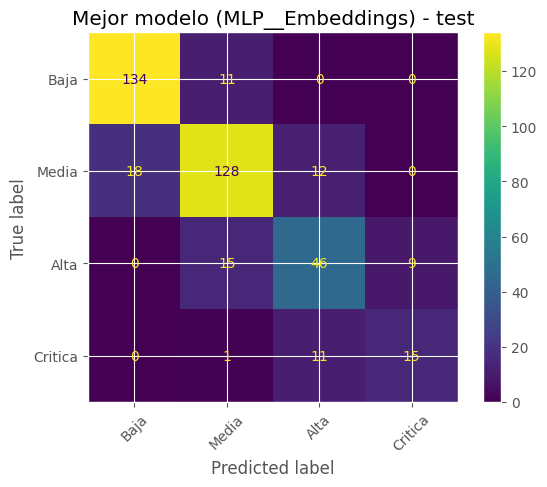

In [33]:
# Recuperamos el run de refit del mejor modelo (su pipeline ya entrenada con train+val).
mejor_refit = runs[(runs["tags.stage"] == "refit_final") & (runs["tags.study_name"] == mejor["study_name"])].iloc[0]
mejor_modelo = mlflow.sklearn.load_model(f"runs:/{mejor_refit['run_id']}/model")

# Evaluación FINAL en test del modelo elegido.
pred_test = mejor_modelo.predict(X_test)
print("Macro recall (test):", round(recall_score(y_test, pred_test, average="macro"), 3))
print(classification_report(y_test, pred_test))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=ORDEN_CLASES, xticks_rotation=45)
plt.title(f"Mejor modelo ({mejor['study_name']}) - test")
plt.show()

Guarda ahora el modelo para utilizarlo en la siguiente fase

In [34]:
import cloudpickle

# El pipeline elegido contiene un tokenizador propio (y se cargó "por valor" desde MLflow),
# así que lo serializamos con cloudpickle para que el artefacto quede autocontenido y portable.
with open("modelo_final.pkl", "wb") as f:
    cloudpickle.dump(mejor_modelo, f)

with mlflow.start_run(run_name=f"modelo_final_{mejor['study_name']}"):
    mlflow.set_tag("stage", "modelo_final")
    mlflow.log_param("modelo_elegido", mejor["study_name"])
    mlflow.log_metric("macro_recall_test", float(recall_score(y_test, pred_test, average="macro")))
    # cloudpickle evita el serializador estricto (skops) que rechaza el tokenizador propio
    mlflow.sklearn.log_model(mejor_modelo, name="modelo_final", serialization_format="cloudpickle")
print("Modelo exportado a modelo_final.pkl")

2026/07/09 03:33:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/09 03:33:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modelo exportado a modelo_final.pkl


Responde:

1. ¿Por qué el conjunto de **test** se lee recién al final y la selección se hace por `macro_recall_val`? **(0.2 pts)**
2. Además de la métrica, ¿qué otros criterios considerarías para elegir el modelo de **producción**? En particular: si el mejor modelo usa **embeddings**, ¿qué implica eso en inferencia (pista: hay que llamar a la API de `gemini-embedding-001`)? **(0.2 pts)**
3. Mira el desempeño **por clase** en test, especialmente `Critica`. ¿El modelo sirve para el objetivo de negocio (priorizar bien los tickets críticos)? **(0.2 pts)**
4. ¿Qué información registrarías en MLflow para que este modelo sea **reproducible y desplegable** por otra persona del equipo? **(0.2 pts)**
5. Mirando todo el barrido, ¿el mejor modelo justifica su complejidad frente a alternativas más simples? ¿Cuál llevarías tú a producción y por qué? **(0.2 pts)**

_Subtotal preguntas: 1.0 pts_

**Responde aquí**

> 1. Las razones son las que ya hemos comentado en preguntas anteriores, pues la idea fundamental es que el conjunto de validación sirva para la selección del mejor modelo e hiperparámetros. Por eso mismo, para hacer esta elección estamos mirando los datos del conjunto de validación, sin embargo, al hacer esta elección, si hicieramos la evaluación sobre este mismo conjunto estariamos sesgando el modelo a ajustarse a estos. Por eso es que el conjunto de testeo `test` nunca debe ser visto por el modelo para que la evaluación sea lo más insesgada posible y de verdad se pueda evaluar el desempeño y capacidad de generalización del modelo.

> 2. Es cierto que las métricas son relevantes, sin embargo, llevar algo a producción requiere recursos tanto en tiempo como costo monetario. En ese sentido, algo a tener en cuenta es la velocidad de inferencia del modelo, el costo por realizar cada inferencia, su desempeño general y su dependencia externa. Mencionamos particularmente costo por inferencia y dependencia externa dado que un modelo que use embeddings requiere llamar a una API (en nuestro caso `gemini-embedding-001`), la cual implica un costo monetario por token y una dependencia de un servicio externo al que no tenemos control directo. Por esto mismo consideramos que, si bien el mejor modelo en macro recall val es claramente **MLP_Embeddings** (0.80), existen opciones muy competitivas que permiten equilibrar los costos mencionados antes y que son mucho más rápidos e "independientes" sin perder demasiado desempeño general y, más aún, funcionando mejor en la clase Crítica. Con esto nos referimos a **RL_BoW** y **RL_Embeddings** los cuales ya fueron discutidos previamente.

> 3. No del todo. Consideramos que el modelo **MLP_Embeddings** pese a tener buenas métricas generales debe estar sesgado por el desbalance de clases mencionado antes que MLP no puede capturar directamente y eso se ve en su "pobre" desempeño en la clase Crítica (0.556 recall en test) frente a **RL_BoW** (0.63) o **RL_Embeddings** (0.78). Sin embargo, queremos destacar que mirando en detalle el desempeño por clase de **MLP_Embeddings** tenemos recalls por clase dados por: `Baja` (0.92), `Media` (0.81), `Alta` (0.66) y `Crítica` (0.56) por tanto el modelo funciona muy bien en las clases bajas y medias y lo mas probable es que los errores que tenga (Falsos Negativos) al detectar mal para la clase Crítica sean tiquets que realmente manda en su mayoría a la clase Alta. Esto desde el punto de vista del negocio podría ser aceptable y podría justificar claramente el uso del modelo, sin embargo creemos que los tres mencionados anteriormente son muy competitivos entre sí y todos son justificables de ser elegidos.

> 4. Para que el modelo sea reproducible y desplegable por otra persona del equipo, registraríamos en MLflow el pipeline completo entrenado y serializado (preprocesamiento + modelo, tal como ya lo hace el ejecutor con log_model), los hiperparámetros de la mejor configuración encontrada, la semilla (SEED) utilizada, los tamaños y forma de los splits (train/val/test) y las métricas obtenidas en val y test generales y por clases. Además, sería importante registrar la versión de las librerías y del entorno (fácilmente con uv). En particular, dado que el modelo elegido usa embeddings, sería importante dejar documentado el modelo y la dimensión exactos (gemini-embedding-001, 1024 dims) y la forma en que se construyó el texto de entrada, ya que en inferencia todo esto debe replicarse de manera idéntica para que el modelo funcione correctamente.

> 5. El mejor modelo según macro recall en validación es **MLP_Embeddings** (0.80), y es el que seleccionamos en esta etapa siguiendo el protocolo de elegir por val. Sin embargo, al analizar si justifica su complejidad, creemos que depende por razones ya mencionadas un poco antes. En test el modelo obtiene 0.737, que no supera a **RL_BoW** (0.752), y además es más caro de entrenar, tiene más hiperparámetros que tunear y depende de la API de embeddings en inferencia. Por eso **RL_BoW** creemos que es una alternativa muy competitiva y bastante más simple, pues obtiene el mejor macro recall en test, es el más rápido en entrenar (9.1s de refit) y no requiere ningún servicio externo, siendo más barato y robusto de desplegar de forma independiente sin servicios externos. Ahora bien, restringiendose solo a la selección por validación, el modelo elegido es **MLP_Embeddings** por un amplio margen (0.80 en val vs el segundo mejor con 0.73). Sin embargo, dependiendo de cuánto se prioricen la simplicidad y el costo operativo,**RL_BoW** sería igualmente defendible, e incluso **RL_Embeddings** entraría en la conversación si el negocio priorizara por sobre todo la detección de la clase Crítica (recall 0.778) aunque a costo de un mayor tiempo de ejecución. **En resumen**, el MLP es el ganador por métrica de validación, pero el estudio muestra que existen alternativas más simples con desempeño comparable que bien podrían justificarse según el criterio del negocio, siendo **RL_BoW** y **RL_Embeddings** igualmente elegibles.